# DSCC 201/401 Final Project -  Question1

**Sherry Wang**

A. Copy the solar_data.tar.gz file from /public/bmort/R. Unpack the
compressed file. Examine the data structure in the tables in each of the individual
files.

In [57]:
# Copy the solar_data.tar.gz file
system("cp /public/bmort/R/solar_data.tar.gz .")

# Unpack the compressed file
system("tar -xzvf solar_data.tar.gz")

# List all files in the directory
files <- list.files("solar_data", full.name = TRUE)
files
cat("Number of data files:", length(files), "\n\n")

# Examine the data structure in the tables
lines <- system("head -30 solar_data/1997_DSD.txt", intern = TRUE)
cat(lines, sep = "\n")

lines <- system("head -30 solar_data/2025Q3_DSD.txt", intern = TRUE)
cat("\n",lines, sep = "\n")

[1] "solar_data/1997_DSD.txt"   "solar_data/1998_DSD.txt"  
 [3] "solar_data/1999_DSD.txt"   "solar_data/2000_DSD.txt"  
 [5] "solar_data/2001_DSD.txt"   "solar_data/2002_DSD.txt"  
 [7] "solar_data/2003_DSD.txt"   "solar_data/2004_DSD.txt"  
 [9] "solar_data/2005_DSD.txt"   "solar_data/2006_DSD.txt"  
[11] "solar_data/2007_DSD.txt"   "solar_data/2008_DSD.txt"  
[13] "solar_data/2009_DSD.txt"   "solar_data/2010_DSD.txt"  
[15] "solar_data/2011_DSD.txt"   "solar_data/2012_DSD.txt"  
[17] "solar_data/2013_DSD.txt"   "solar_data/2014_DSD.txt"  
[19] "solar_data/2015_DSD.txt"   "solar_data/2016_DSD.txt"  
[21] "solar_data/2017_DSD.txt"   "solar_data/2017Q4_DSD.txt"
[23] "solar_data/2018_DSD.txt"   "solar_data/2018Q1_DSD.txt"
[25] "solar_data/2018Q2_DSD.txt" "solar_data/2018Q3_DSD.txt"
[27] "solar_data/2018Q4_DSD.txt" "solar_data/2019Q1_DSD.txt"
[29] "solar_data/2019Q2_DSD.txt" "solar_data/2019Q3_DSD.txt"
[31] "solar_data/2019Q4_DSD.txt" "solar_data/2020Q1_DSD.txt"
[33] "solar_data/2020Q2_DSD.txt" "solar_data/2020Q3_DSD.txt"
[35] "solar_data/2020Q4_DSD.txt" "solar_data/2021Q1_DSD.txt"
[37] "solar_data/2021Q2_DSD.txt" "solar_data/2021Q3_DSD.txt"
[39] "solar_data/2021Q4_DSD.txt" "solar_data/2022Q1_DSD.txt"
[41] "solar_data/2022Q2_DSD.txt" "solar_data/2022Q3_DSD.txt"
[43] "solar_data/2022Q4_DSD.txt" "solar_data/2023Q1_DSD.txt"
[45] "solar_data/2023Q2_DSD.txt" "solar_data/2023Q3_DSD.txt"
[47] "solar_data/2023Q4_DSD.txt" "solar_data/2024Q1_DSD.txt"
[49] "solar_data/2024Q2_DSD.txt" "solar_data/2024Q3_DSD.txt"
[51] "solar_data/2024Q4_DSD.txt" "solar_data/2025Q1_DSD.txt"
[53] "solar_data/2025Q2_DSD.txt" "solar_data/2025Q3_DSD.txt"
[55] "solar_data/2025Q4_DSD.txt"

Number of data files: 55 

:Product: Daily Solar Data         1997_DSD.txt
:Issued: 1900 UT 17 Dec 1998
#
#  Prepared by the U.S. Dept. of Commerce, NOAA, Space Environment Center.
#  Please send comments and suggestions to sec@sec.noaa.gov
#
#                            1997 Daily Solar Data
#
                          Sunspot       Stanford GOES9
            Radio  SESC     Area          Solar  X-Ray  ------ Flares ------
            Flux  Sunspot  10E-6   New     Mean  Bkgd    X-Ray      Optical
   Date     10.7cm Number  Hemis. Regions Field  Flux   C  M  X  S  1  2  3
1997 01 01   72      0        0      0       *   A0.5   0  0  0 -1 -1 -1 -1
1997 01 02   72      0        0      0       *   A0.5   0  0  0 -1 -1 -1 -1
1997 01 03   73      0        0      0       3   A0.5   0  0  0 -1 -1 -1 -1
1997 01 04   74     13       10      1       *   A0.6   0  0  0 -1 -1 -1 -1
1997 01 05   74     15       20      0       5   A0.7   0  0  0 -1 -1 -1 -1
1997 01 06   73     15       10      0  

These files are **whitespace-separated** ASCII text tables containing daily NOAA solar activity observations.  
The file structure consists of three parts:  
(1) a metadata header at the top  
(2) multi-line ASCII-formatted column headings  
(3) daily data records beginning with the date in the form YYYY MM DD  

Missing values are encoded as `-1`, `-999`, or `*`. All yearly and quarterly files almost share the same overall structure.

B. Preprocess the files in the Linux command line environment and then load the data from all years into a data frame in R. Produce a table of summary statistics on the data set. How do the ranges of the values in the columns with numerical data compare? Does each column of numerical data have similar magnitudes and ranges? Are there any outliers? Is there any missing data? Perform any data imputation or data modification as part of the data clean up process. Explain the reasoning for all actions taken.

In [81]:
# 1. Preprocess the files in the Linux command line environment

# As required, I first used Linux commands (called through system() in R) 
# to inspect and prepare the raw files:
# Used 'cp' to copy the compressed dataset into the working directory.
# Used 'tar -xzvf' to unpack the archive and extract all yearly/quarterly files.
# Used 'head' to examine the file structure.
# All these preprocessing steps have been finished in part A

# 2. Load the data from all years into a data frame in R

# Define a file-reading function
read_solar <- function(path) {
  # Skip the header line and detect the first sample
  raw <- readLines(path)
  data_start <- grep("^ *[0-9]{4}", raw)[1]
  
  df <- read.table(
    path,
    header = FALSE,
    comment.char = "#",
    fill = TRUE,
    skip = data_start - 1
  )
  
  # Add column names
  colnames(df) <- c(
    "Year", "Month", "Day",
    "Radio_Flux_10.7_cm",
    "SESC_Sunspot_Number",
    "Sunspot_Area",
    "New_Regions",
    "Stanford_Solar_Mean_Field",
    "GOES15_XRay_Bkgd_Flux",
    "XRay_C",
    "XRay_M",
    "XRay_X",
    "S",
    "Optical_1",
    "Optical_2",
    "Optical_3"
  )
  
  # Add Date column
  df$Date <- as.Date(
    with(df, sprintf("%04d-%02d-%02d", Year, Month, Day)),
    format = "%Y-%m-%d"
  )
  
  # Drop Year, Month, Day
  df <- subset(df, select = -c(Year, Month, Day))
  
  # Put Date as first column
  df <- df[, c("Date", setdiff(names(df), "Date"))]

  # Columns that should be numeric (everything except Date + XRay_Bkgd_Flux string)
  num_cols <- setdiff(names(df), c("Date", "GOES15_XRay_Bkgd_Flux"))
  df[num_cols] <- lapply(df[num_cols], function(x) {
    if (is.factor(x)) x <- as.character(x)
    suppressWarnings(as.numeric(x))
  })
    
  df$GOES15_XRay_Bkgd_Flux <- as.character(df$GOES15_XRay_Bkgd_Flux)

  return(df)
}

# Read all files as a dataframe
df_all <- do.call(rbind, lapply(files, read_solar))
cat("Dataset dimensions: ", nrow(df_all), "rows, ", ncol(df_all), "columns\n")

# Inspect the first few rows
print(head(df_all))

# 3. Produce a table of summary statistics on the dataset
summary(df_all)

# Check for duplicate dates
cat("# Duplicate dates", sum(duplicated(df_all$Date)), "\n")
# Remove fully duplicated rows (same Date and same values in all columns)
# caused by reading both yearly and quarterly DSD files
df_all <- df_all[!duplicated(df_all), ]
# Double check for duplicate dates
cat("# Duplicate dates after manipulation", sum(duplicated(df_all$Date)), "\n")
cat("# Dataset dimensions: ", dim(df_all)[1], "rows, ", dim(df_all)[2], "columns\n")

# Check missing values for Date and XRay_Bkgd
cat("# Missing values for Date: ", sum(is.na(df_all$Date)), "\n")
cat("# Missing values for XRay_Bkgd remarked as '*': ", 
    sum(df_all$GOES15_XRay_Bkgd_Flux == "*", na.rm = TRUE), "\n")

make_summary <- function(df) {
  
  num_cols <- names(df)[sapply(df, is.numeric)]

  summary_table <- data.frame(
    Min      = sapply(df[num_cols], min, na.rm = TRUE),
    Q1       = sapply(df[num_cols], quantile, probs = 0.25, na.rm = TRUE),
    Median   = sapply(df[num_cols], median, na.rm = TRUE),
    Mean     = sapply(df[num_cols], function(x) round(mean(x, na.rm = TRUE), 2)),
    Q3       = sapply(df[num_cols], quantile, probs = 0.75, na.rm = TRUE),
    Max      = sapply(df[num_cols], max, na.rm = TRUE),
    Missing  = sapply(df[num_cols], function(x) sum(is.na(x)))
  )

  return(summary_table)
}

# Summary for numeric variables
summary_df <- make_summary(df_all)
library(knitr)
kable(summary_df, 
      caption = "Summary statistics for all numeric variables",
      digits = 2)                      

Dataset dimensions:  11000 rows,  14 columns
        Date Radio_Flux_10.7_cm SESC_Sunspot_Number Sunspot_Area New_Regions
1 1997-01-01                 72                   0            0           0
2 1997-01-02                 72                   0            0           0
3 1997-01-03                 73                   0            0           0
4 1997-01-04                 74                  13           10           1
5 1997-01-05                 74                  15           20           0
6 1997-01-06                 73                  15           10           0
  Stanford_Solar_Mean_Field GOES15_XRay_Bkgd_Flux XRay_C XRay_M XRay_X  S
1                        NA                  A0.5      0      0      0 -1
2                        NA                  A0.5      0      0      0 -1
3                         3                  A0.5      0      0      0 -1
4                        NA                  A0.6      0      0      0 -1
5                         5                  A

      Date            Radio_Flux_10.7_cm SESC_Sunspot_Number  Sunspot_Area    
 Min.   :1997-01-01   Min.   : 64        Min.   :  0.00      Min.   :      0  
 1st Qu.:2004-07-12   1st Qu.: 74        1st Qu.: 13.00      1st Qu.:     20  
 Median :2012-01-23   Median : 99        Median : 53.00      Median :    280  
 Mean   :2011-09-21   Mean   :112        Mean   : 69.38      Mean   :   1235  
 3rd Qu.:2018-09-02   3rd Qu.:140        3rd Qu.:112.00      3rd Qu.:    730  
 Max.   :2025-11-13   Max.   :343        Max.   :401.00      Max.   :8348570  
                                                                              
  New_Regions     Stanford_Solar_Mean_Field GOES15_XRay_Bkgd_Flux
 Min.   :0.0000   Min.   :-999.0            Length:11000         
 1st Qu.:0.0000   1st Qu.:-999.0            Class :character     
 Median :0.0000   Median :-999.0            Mode  :character     
 Mean   :0.5737   Mean   :-907.6                                 
 3rd Qu.:1.0000   3rd Qu.:-999.0      

# Duplicate dates 457 
# Duplicate dates after manipulation 0 
# Dataset dimensions:  10543 rows,  14 columns
# Missing values for Date:  0 
# Missing values for XRay_Bkgd remarked as '*':  2108 




|                          |  Min|   Q1| Median|    Mean|   Q3|     Max| Missing|
|:-------------------------|----:|----:|------:|-------:|----:|-------:|-------:|
|Radio_Flux_10.7_cm        |   64|   75|    102|  113.75|  142|     343|       0|
|SESC_Sunspot_Number       |    0|   14|     57|   72.09|  115|     401|       0|
|Sunspot_Area              |    0|   40|    310| 1287.68|  760| 8348570|       0|
|New_Regions               |    0|    0|      0|    0.59|    1|       6|       0|
|Stanford_Solar_Mean_Field | -999| -999|   -999| -903.67| -999|     147|      36|
|XRay_C                    |   -1|    0|      1|    2.98|    5|      30|       0|
|XRay_M                    |   -1|    0|      0|    0.37|    0|      22|       0|
|XRay_X                    |   -1|    0|      0|    0.03|    0|       4|       0|
|S                         |   -1|    0|      1|    3.65|    5|      55|       0|
|Optical_1                 |   -1|    0|      0|    0.25|    0|       8|       0|
|Optical_2    

How do the ranges of the values in the columns with numerical data compare? Does each column of numerical data have similar magnitudes and ranges? Are there any outliers? Is there any missing data?  

The numerical columns show **highly variable ranges and magnitudes**, and they do not operate on comparable scales. For example, `Radio_Flux_10.7_cm` ranges from 64 to 343, while `SESC_Sunspot_Number` spans 0 to 401. `Sunspot_Area` has an **extremely large upper bound of 8,348,570**, which is  significantly larger than any other measurement and indicates the presence of **outliers**. **The flare-related variables** (XRay_C, XRay_M, XRay_X, S, Optical_1/2/3) have very **small ranges** (typically –1 to at most 55), reflecting their nature as sparse count data.

The column `Stanford_Solar_Mean_Field` is dominated by the sentinel value `-999`, with only a small number of valid measurements. This indicates **large missing data in this variable**. Besides that, missingness also comes from **non-numeric placeholder (`*`) in this column** which has been recognized when reading all files in R. **Several flare and optical variables** also use `-1` as **a sentinel value for missing values**.

In the `GOES15_XRay_Bkgd_Flux` column, the placeholder value `*` indicates an invalid or unreported flux measurement and does not correspond to any physical X-Ray flux class. Therefore, it is treated as a **missing value**.

Overall, the numerical variables differ greatly in scale and distribution. Large physical measurements such as `Sunspot_Area` contain extreme high-end values (clear outliers), while flare count variables remain close to zero. Several columns contain missing data (`-1`, `-999`, `*`), which require cleaning and imputation before implementing ML models.

In [82]:
# 4. Perform data imputation or data modification

# Based on summary, outlier lies in Sunspot_Area. 
# Check outliers using the reasonable threshold
df_before_clean <- df_all 
cat("Outlier values of Sunspot_Area:", 
    df_before_clean$Sunspot_Area[df_before_clean$Sunspot_Area > 10000])

library(dplyr)
# Recode sentinel values to NA
sentinel_neg999_cols <- c("Stanford_Solar_Mean_Field")

flare_optical_cols <- c(
  "XRay_C", "XRay_M", "XRay_X", "S",
  "Optical_1", "Optical_2", "Optical_3"
)

df_all <- df_all %>%
  mutate(
    across(all_of(sentinel_neg999_cols),
           ~ ifelse(.x == -999, NA, .x)),
    across(all_of(flare_optical_cols),
           ~ ifelse(.x == -1, NA, .x))
  )

# Recode placeholder values to NA
df_all$GOES15_XRay_Bkgd_Flux[df_all$GOES15_XRay_Bkgd_Flux == "*"] <- NA

# Treat extreme Sunspot_Area as missing values
df_all <- df_all %>%
  mutate(
    Sunspot_Area = ifelse(Sunspot_Area > 10000, NA, Sunspot_Area)
  )

# Check the proportion of missing values after cleaning
missing_table <- data.frame(
  Variable = names(df_all),
  Missing_Percent_After_Cleaning = sprintf("%.2f%%", colMeans(is.na(df_all)) * 100)
)

kable(missing_table)


# Handle Missing values
library(tidyr)
df_clean <- df_all %>% drop_na(Sunspot_Area) #Remove outlier row
df_clean <- df_clean %>%
  select(-Stanford_Solar_Mean_Field) #Remove high-missing variable

low_missing_cols <- c("XRay_C", "XRay_M", "XRay_X", "S",
                      "Optical_1", "Optical_2", "Optical_3")

# Imputation with median value
df_clean <- df_clean %>%
  mutate(across(all_of(low_missing_cols),
                ~ ifelse(is.na(.x), median(.x, na.rm = TRUE), .x))) 

# Check the proportion of missing values after missing value imputation
missing_table <- data.frame(
  Variable = names(df_clean),
  Missing_Percent_After_Missing_Value_Imputation = sprintf(
      "%.2f%%", 
      colMeans(is.na(df_clean)) * 100)
)

kable(missing_table)

# Check the distributions after missing value imputation
summary_df_clean <- make_summary(df_clean)
kable(summary_df_clean)

Outlier values of Sunspot_Area: 8348570



|Variable                  |Missing_Percent_After_Cleaning |
|:-------------------------|:------------------------------|
|Date                      |0.00%                          |
|Radio_Flux_10.7_cm        |0.00%                          |
|SESC_Sunspot_Number       |0.00%                          |
|Sunspot_Area              |0.01%                          |
|New_Regions               |0.00%                          |
|Stanford_Solar_Mean_Field |90.52%                         |
|GOES15_XRay_Bkgd_Flux     |19.99%                         |
|XRay_C                    |0.01%                          |
|XRay_M                    |0.01%                          |
|XRay_X                    |0.01%                          |
|S                         |0.85%                          |
|Optical_1                 |0.85%                          |
|Optical_2                 |0.85%                          |
|Optical_3                 |0.85%                          |



|Variable              |Missing_Percent_After_Missing_Value_Imputation |
|:---------------------|:----------------------------------------------|
|Date                  |0.00%                                          |
|Radio_Flux_10.7_cm    |0.00%                                          |
|SESC_Sunspot_Number   |0.00%                                          |
|Sunspot_Area          |0.00%                                          |
|New_Regions           |0.00%                                          |
|GOES15_XRay_Bkgd_Flux |19.99%                                         |
|XRay_C                |0.00%                                          |
|XRay_M                |0.00%                                          |
|XRay_X                |0.00%                                          |
|S                     |0.00%                                          |
|Optical_1             |0.00%                                          |
|Optical_2             |0.00%                    



|                    | Min| Q1| Median|   Mean|  Q3|  Max| Missing|
|:-------------------|---:|--:|------:|------:|---:|----:|-------:|
|Radio_Flux_10.7_cm  |  64| 75|    102| 113.76| 142|  343|       0|
|SESC_Sunspot_Number |   0| 14|     57|  72.10| 115|  401|       0|
|Sunspot_Area        |   0| 40|    310| 495.87| 760| 5690|       0|
|New_Regions         |   0|  0|      0|   0.59|   1|    6|       0|
|XRay_C              |   0|  0|      1|   2.98|   5|   30|       0|
|XRay_M              |   0|  0|      0|   0.37|   0|   22|       0|
|XRay_X              |   0|  0|      0|   0.03|   0|    4|       0|
|S                   |   0|  0|      1|   3.67|   5|   55|       0|
|Optical_1           |   0|  0|      0|   0.26|   0|    8|       0|
|Optical_2           |   0|  0|      0|   0.05|   0|    4|       0|
|Optical_3           |   0|  0|      0|   0.01|   0|    2|       0|

Explain the reasoning for all cleaning actions taken.

We first recoded sentinel codes to proper NA. Measurements of the `Stanford_Solar_Mean_Field` use `-999` to indicate **missing values**, and the flare-related variables use `-1` to indicate unreported counts. These were converted to NA for consistency.
We also identified one **extreme outlier** in `Sunspot_Area` (`8,348,570`), far beyond any physically possible value (normally <6,000), and recoded it as NA.

To handle missing values in the dataset, we applied **different strategies** depending on the nature and frequency of missingness in each variable.
First, we **removed the row containing the extreme outlier** in `Sunspot_Area` (`8,348,570`), which was previously recoded as NA. This value is physically impossible, so deleting this single row prevents distortion of data.
Next, we **excluded the `Stanford_Solar_Mean_Field` variable entirely**. This column contained more than **90% missing values**, making imputation unreliable and potentially misleading. Thus, removing the column is the most appropriate solution.
For variables with very low missing rates (`XRay_C`, `XRay_M`, `XRay_X`, `S`, `Optical_1`, `Optical_2`, `Optical_3`), we performed **median imputation**. Using the median preserves the central tendency of the distribution without creating unrealistic values.  

Since `GOES15_XRay_Bkgd_Flux` is a **categorical variable** and the missingness affects only this single field (with all other variables on the same row remaining valid), we retained those rows and **kept the `NA` values**.

C. Export your final clean data frame with all data combined from each of the years to a single csv file (solar_data_clean.csv).

In [45]:
# Export the final clean dataframe as a csv file
write.csv(df_clean, "solar_data_clean.csv", row.names = FALSE)
list.files(pattern = "solar_data")

cat("#Final Dataset dimensions: ", 
    dim(df_clean)[1], "rows, ", 
    dim(df_clean)[2], "columns\n")

[1] "solar_data"           "solar_data_clean.csv" "solar_data.tar.gz"

#Final Dataset dimensions:  10542 rows,  13 columns


D. Which day(s) had the highest value for the radio flux? Which day(s) had the lowest
value for the radio flux?

In [77]:
# Highest radio flux
max_flux <- max(df_clean$Radio_Flux_10.7_cm, na.rm = TRUE)
highest_days <- df_clean[df_clean$Radio_Flux_10.7_cm == max_flux, 
                         c("Date", "Radio_Flux_10.7_cm")]

kable(highest_days)

# Lowest radio flux
min_flux <- min(df_clean$Radio_Flux_10.7_cm, na.rm = TRUE)
lowest_days <- df_clean[df_clean$Radio_Flux_10.7_cm == min_flux, 
                        c("Date", "Radio_Flux_10.7_cm")]

kable(lowest_days)



|      |Date       | Radio_Flux_10.7_cm|
|:-----|:----------|------------------:|
|10000 |2023-02-17 |                343|



|     |Date       | Radio_Flux_10.7_cm|
|:----|:----------|------------------:|
|8785 |2019-10-21 |                 64|

E. Which day(s) had the greatest number of solar flares? How many days had no solar
flares?

In [78]:
# Calculate the total flares = C + M + X + S + Optical_1 + Optical_2 + Optical_3
df_clean$total_flares <- df_clean$XRay_C +
                         df_clean$XRay_M +
                         df_clean$XRay_X +
                         df_clean$S +
                         df_clean$Optical_1 +
                         df_clean$Optical_2 +
                         df_clean$Optical_3

# Day(s) with the greatest number of solar flares
max_flares <- max(df_clean$total_flares, na.rm = TRUE)
days_with_max_flares <- df_clean[df_clean$total_flares == max_flares,
                                 c("Date", "total_flares")]
kable(days_with_max_flares)

cat(
  "The day(s) with the greatest number of solar flares is/are: \n",
  paste(days_with_max_flares$Date, collapse = ", "),
  " with a total of ", max_flares, " flares.\n",
  sep = ""
)

# Number of days with zero solar flares
zero_flare_days <- sum(df_clean$total_flares == 0)
cat("Number of days without solar flares:", zero_flare_days)



|     |Date       | total_flares|
|:----|:----------|------------:|
|9994 |2023-02-11 |           74|

The day(s) with the greatest number of solar flares is/are: 
2023-02-11 with a total of 74 flares.
Number of days without solar flares: 3843

F. Create a single boxplot of the radio flux data. The y axis should be the solar radio
flux and the x axis should be year.

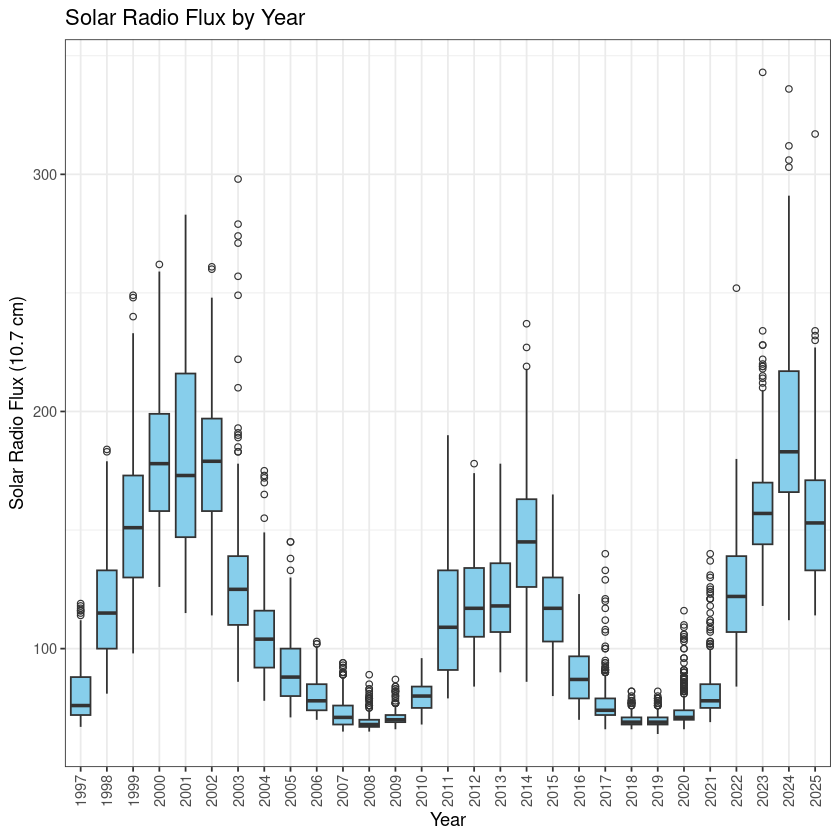

In [48]:
# Extract year value from date
df_clean$Year <- format(df_clean$Date, "%Y")

# Draw side-by-side boxplots
library(ggplot2)

ggplot(df_clean, aes(x = Year, y = Radio_Flux_10.7_cm)) +
  geom_boxplot(fill = "skyblue", outlier.shape = 1) +
  labs(
    title = "Solar Radio Flux by Year",
    x = "Year",
    y = "Solar Radio Flux (10.7 cm)"
  ) +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 90, vjust = 0.5))

The yearly boxplot reveals **clear cyclical patterns** in the **solar radio flux**.
**High flux values and greater variability** occur around **2000–2002, 2013–2015, and 2023–2025**, corresponding to solar cycle peaks.
In contrast, the years **2008–2009 and 2018–2019** show **very low flux and minimal variability**, indicating solar minimum periods.

G. Partition the data set so that a random sample of 80% of the data will be used for training and 20% will be used for testing your machine learning model. The partition can be done randomly or the `createDataPartition()` function in R's caret library can be used.

In [49]:
library(caret)

set.seed(123)

# Create the partition index (stratified sampling based on Radio Flux)
train_index <- createDataPartition(df_clean$Radio_Flux_10.7_cm, 
                                   p = 0.8, 
                                   list = FALSE)

# Split the data
train_data <- df_clean[train_index, ]
test_data  <- df_clean[-train_index, ]

cat("Training set size:", nrow(train_data), "\n")
cat("Test set size:", nrow(test_data), "\n")

Training set size: 8435 
Test set size: 2107 


H. Generate a linear regression model to predict the solar flux from the sunspot number and the individual number of X-ray and optical solar flares.

In [50]:
lm_model <- lm(
  Radio_Flux_10.7_cm ~ 
    SESC_Sunspot_Number +
    XRay_C + XRay_M + XRay_X +
    S + Optical_1 + Optical_2 + Optical_3,
  data = train_data
)

summary(lm_model)


Call:
lm(formula = Radio_Flux_10.7_cm ~ SESC_Sunspot_Number + XRay_C + 
    XRay_M + XRay_X + S + Optical_1 + Optical_2 + Optical_3, 
    data = train_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-80.678  -7.751  -1.336   5.686 130.271 

Coefficients:
                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)         69.452597   0.255603 271.721  < 2e-16 ***
SESC_Sunspot_Number  0.535474   0.003632 147.442  < 2e-16 ***
XRay_C               1.374153   0.061525  22.335  < 2e-16 ***
XRay_M               4.596153   0.203657  22.568  < 2e-16 ***
XRay_X               9.351812   1.088890   8.588  < 2e-16 ***
S                   -0.005983   0.044417  -0.135  0.89285    
Optical_1           -1.030698   0.324131  -3.180  0.00148 ** 
Optical_2            0.601293   0.749049   0.803  0.42215    
Optical_3            3.981631   2.196817   1.812  0.06995 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 15.77 on 8426 degree

I. Use the 20% of the data set aside for testing to determine the accuracy of your model. Choose an appropriate accuracy metric. How well does your model predict the solar radio flux from the sunspot number and number and type of solar flares? Comment on why the accuracy is good or poor.

In [51]:
# Use test set for prediction
pred <- predict(lm_model, newdata = test_data)

# linear regression evaluation metrics: RMSE, MAE and R-squared
rmse <- sqrt(mean((pred - test_data$Radio_Flux_10.7_cm)^2))
mae  <- mean(abs(pred - test_data$Radio_Flux_10.7_cm))

SSE <- sum((pred - test_data$Radio_Flux_10.7_cm)^2)
SST <- sum((mean(test_data$Radio_Flux_10.7_cm) - 
             test_data$Radio_Flux_10.7_cm)^2)

R2 <- 1 - SSE/SST

cat("Test RMSE:", rmse, "\n")
cat("Test MAE:", mae, "\n")
cat("Test R-squared:", R2, "\n")

Test RMSE: 16.11226 
Test MAE: 10.66703 
Test R-squared: 0.8655497 


**RMSE**, **MAE** and **R-squared** are the three **standard regression metrics** when evaluating the linear regression model's performance. On the test dataset, the model achieves:  
- RMSE = 16.11  
- MAE = 10.67  
- R-squared = 0.87  

Given that the solar radio flux ranges from 64 to 343 (a span of 279 units), the model’s RMSE of 16.11 and MAE of 10.67 represent **approximately 6% and 4% of the total range **separately. This indicates that the linear regression model expresses very strong predictive accuracy in solar radio flux.
An R-squared of 0.87 indicates that the model explains **87% of the variation in solar radio flux** using given explanatory variables.

This level of accuracy is quite strong for a mutiple linear regression model.


J. What is the predicted radio flux for a day when 73 sunspots are observed on the sun and 2 solar flares with C-class energy levels and 1 solar flare with an M-class energy level occur? How confident are you in the answer? Explain your reasoning.

In [79]:
# The given values of the explanatory variables
new_day <- data.frame(
  SESC_Sunspot_Number = 73,
  XRay_C  = 2,
  XRay_M  = 1,
  XRay_X  = 0,
  S       = 0,
  Optical_1 = 0,
  Optical_2 = 0,
  Optical_3 = 0
)

#Construct 95% prediction interval 
# based on the given values of the explanatory variables
pred_CI <- predict(lm_model, newdata = new_day,
                   interval = "prediction", level = 0.95)

kable(pred_CI)



|      fit|      lwr|      upr|
|--------:|--------:|--------:|
| 115.8866| 84.95992| 146.8134|

Given the specified explanatory variable values, the linear regression model predicts **an estimated solar radio flux of 115.9**, with a corresponding **95% prediction interval of 85.0 to 146.8**.
I'm **95% confident** that the true radio flux of 73 sunspots, 2 C-class flares, and 1 M-class flare and no other flares lies between **85.0 and 146.8**.

This is a **reliable prediction** based on **our model's strong preditive ability** (RMSE = 16.11, MAE = 10.67, and R-squared = 0.87).
Moreover, the values 73 sunspots, 2 C-class flares, and 1 M-class flare all fall well within the range of the training set, so the model is **interpolating rather than extrapolating**.